Building Geometry...
Geometry - Done.
Building 'Island' Hamiltonian...
'Island' Hamiltonian Done.
Calculating 'Island' Eigenvalues...
'Island' Eigenvalues Done


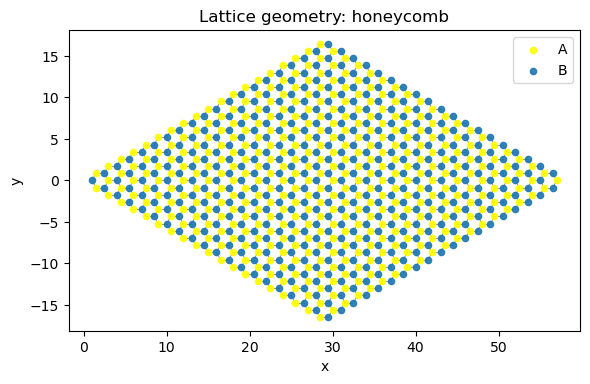

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from topological_insulator import Problem

structure_path = "/Users/vedantdubey/Desktop/UCL/Year 4/PHAS0097 - Physics Project/topological_insulator-main/data/structures"

N_r = 20

problem = Problem(structure_path=structure_path, structure_name="honeycomb.json")
problem.setup(
    N_r=N_r,
    N_k=1,
    location="island",
    BZ="reduced",
    dangling_bonds=False
)
problem.run(H_type="real")

geom = problem.geometry
tb = problem.hamiltonian["island"]["tight_binding"]

problem.plot(plot_type="lattice")

E = np.array(tb.E)
U = np.array(tb.U)
sites = np.array(geom.sites)
N = len(sites)

edge_set = set(getattr(geom, "edge_indices", []))
C = geom.nn_connectivity_matrix

Total states: 798
States with |E| < 0.1: 22


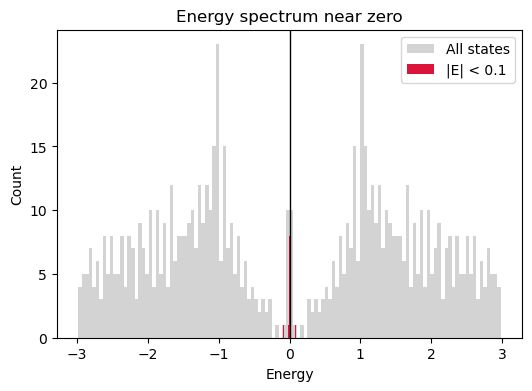

Number of states with |E| < 0.1: 22
Index Number and Energy of states near zero:
  399   6.849296e-10
  398  -6.849324e-10
  397  -1.584653e-08
  400   1.584653e-08
  401   2.460543e-07
  396  -2.460543e-07
  395  -2.721304e-06
  402   2.721304e-06
  394  -2.306153e-05
  403   2.306153e-05
  404   1.545126e-04
  393  -1.545126e-04
  405   8.364595e-04
  392  -8.364595e-04
  391  -3.691663e-03
  406   3.691663e-03
  390  -1.324770e-02
  407   1.324770e-02
  408   3.805127e-02
  389  -3.805127e-02
  388  -8.652541e-02
  409   8.652541e-02


In [14]:
# Energy window
E_cut = 0.1

mask = np.abs(E) < E_cut
E_near0 = E[mask]

print(f"Total states: {len(E)}")
print(f"States with |E| < {E_cut}: {len(E_near0)}")

plt.figure(figsize=(6,4))
plt.hist(E, bins=120, color="lightgray", label="All states")
plt.hist(E_near0, bins=30, color="crimson", label=f"|E| < {E_cut}")
plt.axvline(0, color="black", lw=1)
plt.xlabel("Energy")
plt.ylabel("Count")
plt.legend()
plt.title("Energy spectrum near zero")
plt.show()

def list_near_zero_states(E, E_cut, max_print=200):
    E = np.asarray(E)
    idx = np.where(np.abs(E) < E_cut)[0]
    idx_sorted = idx[np.argsort(np.abs(E[idx]))]  # closest to 0 first

    print(f"Number of states with |E| < {E_cut}: {len(idx_sorted)}")
    print("Index Number and Energy of states near zero:")
    for k, i in enumerate(idx_sorted[:max_print]):
        print(f"{int(i):5d}  {E[i]: .6e}")

    if len(idx_sorted) > max_print:
        print(f"... (showing first {max_print} of {len(idx_sorted)})")

    return idx_sorted

# Example usage:
near_idx = list_near_zero_states(E, E_cut)


In [3]:
# pick vacancy (reuse same logic)
centre = np.mean(sites, axis=0)
d = np.sum((sites - centre)**2, axis=1)
vac_idx = int(np.argmin(d))

def neighbours(idx):
    return np.where(C[idx] == 1)[0]

vac_nb = set(neighbours(vac_idx))
edge_nb = set(edge_set)

bulk_set = set(range(N)) - edge_nb - vac_nb


In [4]:
# Function to compute probability density for the LDOS
def prob_density(j):
    p = np.abs(U[:, j])**2
    return p / p.sum()

edge_weights = []
vac_weights  = []
bulk_weights = []

for j in range(len(E)):
    p = prob_density(j)
    edge_weights.append(np.sum(p[list(edge_nb)]))
    vac_weights.append(np.sum(p[list(vac_nb)]))
    bulk_weights.append(np.sum(p[list(bulk_set)]))

# Checking weights sum to 1
print(f"Checking weights sum to 1: {np.mean(np.array(edge_weights) + np.array(vac_weights) + np.array(bulk_weights))}")


Checking weights sum to 1: 1.0


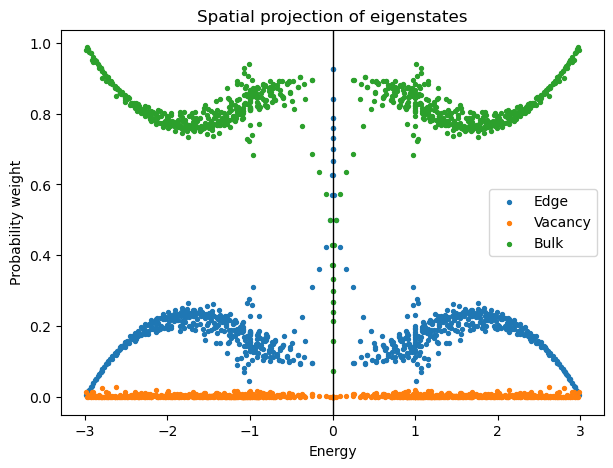

In [23]:
# Plotting spatial projection of eigenstates
plt.figure(figsize=(7,5))
plt.scatter(E, edge_weights, s=8, label="Edge")
plt.scatter(E, vac_weights, s=8, label="Vacancy")
plt.scatter(E, bulk_weights, s=8, label="Bulk")
plt.axvline(0, color="black", lw=1)
plt.xlabel("Energy")
plt.ylabel("Probability weight")
plt.legend()
plt.title("Spatial projection of eigenstates")
plt.show()


In [6]:
# LDOS calculation using Lorentzian broadening
def lorentzian(E, E0, eta):
    return eta / ((E - E0)**2 + eta**2)

eta = 0.03
E_grid = np.linspace(E.min(), E.max(), 1200)

LDOS_edge = np.zeros_like(E_grid)
LDOS_vac  = np.zeros_like(E_grid)
LDOS_bulk = np.zeros_like(E_grid)

for j, Ej in enumerate(E):
    L = lorentzian(E_grid, Ej, eta)
    LDOS_edge += edge_weights[j] * L
    LDOS_vac  += vac_weights[j]  * L
    LDOS_bulk += bulk_weights[j] * L


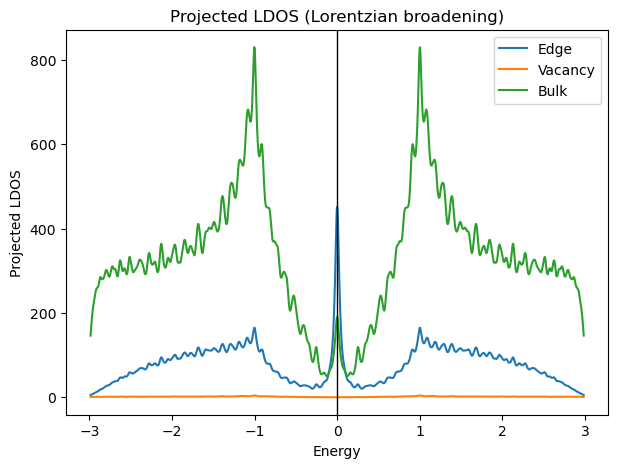

In [22]:
plt.figure(figsize=(7,5))
plt.plot(E_grid, LDOS_edge, label="Edge")
plt.plot(E_grid, LDOS_vac, label="Vacancy")
plt.plot(E_grid, LDOS_bulk, label="Bulk")
plt.axvline(0, color="black", lw=1)
plt.xlabel("Energy")
plt.ylabel("Projected LDOS")
plt.legend()
plt.title("Projected LDOS (Lorentzian broadening)")
plt.show()


In [ ]:
x = sites[:, 0]
y = sites[:, 1]
Lx = x.max() - x.min()
Ly = y.max() - y.min()

print("Estimated island size:")
print("  Lx =", Lx)
print("  Ly =", Ly)

# Fermi velocity in graphene NN model units 
# If coordinate system is such that nearest-neighbour distance a ~ 1, and in ħ=1 units:
t = -1.0
a = 1.0
hbar = 1.0
vF = 3.0 * abs(t) * a / (2.0 * hbar) # Fermi velocity found by linearising graphene bandstructure near Dirac point

# Dirac point is at E=0 in this model

print("Assumed vF (units):", vF)

# Predicting a few low-energy "standing-wave" levels
def predicted_dirac_levels(Lx, Ly, vF, nmax=6, mmax=6):
    levels = []
    for n in range(1, nmax+1):
        for m in range(0, mmax+1):
            qx = n*np.pi/Lx
            qy = m*np.pi/Ly
            E = vF * np.sqrt(qx*qx + qy*qy)
            levels.append(E)
    levels = np.array(sorted(levels))
    return levels

E_pred = predicted_dirac_levels(Lx, Ly, vF, nmax=8, mmax=8)

print("First ~15 predicted |E| values from Dirac standing-wave model:")
print(E_pred[:15])


Estimated island size:
  Lx = 56.0
  Ly = 32.90896534380867
Assumed vF (units): 1.5
First ~15 predicted |E| values from Dirac standing-wave model:
[0.0841498  0.16609006 0.16829961 0.22097393 0.25244941 0.29023339
 0.29849634 0.33218012 0.33659921 0.36579195 0.38177163 0.42074902
 0.43774839 0.44194785 0.44444848]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import topological_insulator
from topological_insulator import Problem
print("Imported from:", topological_insulator.__file__)
importlib.reload(topological_insulator)

# Correct import path (same one you used in KM case style)
from topological_insulator.python.hamiltonian.tight_binding.island_tb import TightBindingIsland

structure_path = "/Users/vedantdubey/Desktop/UCL/Year 4/PHAS0097 - Physics Project/topological_insulator-main/data/structures"
N_r = 20

problem = Problem(structure_path=structure_path, structure_name="honeycomb.json")
problem.setup(N_r=N_r, N_k=1, location="island", BZ="reduced", dangling_bonds=False)
problem.run(H_type="real")

geom  = problem.geometry
sites = np.asarray(geom.sites, dtype=float)
N = len(sites)

edge_set = set(geom.edge_indices)
print("Geometry:")
print("  N sites:", N)
print("  edge sites:", len(edge_set))
assert len(edge_set) > 0

C = geom.nn_connectivity_matrix.astype(int)

# Clean NN TB
tb = TightBindingIsland(problem.model_options, problem.cell_parser)

# If JSON has t=0, override
tb.t = getattr(tb, "t", -1.0)
if tb.t is None or np.isclose(tb.t, 0.0):
    tb.t = -1.0

tb.build_hamiltonian(geom)
tb.solve_eigenvalues(geom, H_type="real")

H_clean = np.asarray(tb.H)   # (N,N)
E0 = np.asarray(tb.E)        # (N,)
U0 = np.asarray(tb.U)        # (N,N) columns eigenvectors

# Site weights for every eigenstate
P0 = np.abs(U0)**2           # (N,N)

print("\nNN clean island:")
print("  dim:", H_clean.shape[0], "(=N)")
print("  eigenvalues:", len(E0))
print("  E min/max:", float(E0.min()), float(E0.max()))
print("  t:", tb.t)


Imported from: /Users/vedantdubey/Desktop/UCL/Year 4/PHAS0097 - Physics Project/topological_insulator-main/src/topological_insulator/__init__.py
Building Geometry...
Geometry - Done.
Building 'Island' Hamiltonian...
'Island' Hamiltonian Done.
Calculating 'Island' Eigenvalues...
'Island' Eigenvalues Done
Geometry:
  N sites: 798
  edge sites: 150
Building 'Island' Hamiltonian...
'Island' Hamiltonian Done.
Calculating 'Island' Eigenvalues...
'Island' Eigenvalues Done

NN clean island:
  dim: 798 (=N)
  eigenvalues: 798
  E min/max: -2.9854424626298717 2.9854424626298717
  t: -1.0


In [6]:
def pick_site_near_point(xy, exclude_edge=False):
    d = np.sum((sites - np.array(xy))**2, axis=1)
    order = np.argsort(d)
    for idx in order:
        if exclude_edge and idx in edge_set:
            continue
        return int(idx)
    return int(order[0])

def neighbours(idx):
    return np.where(C[idx] == 1)[0]

centre = np.mean(sites, axis=0)
vac_bulk = pick_site_near_point(centre, exclude_edge=True)

# Edge site choice (same style as KM fix): choose rightmost edge site
edge_idx = np.array(sorted(list(edge_set)), dtype=int)
vac_edge = int(edge_idx[np.argmax(sites[edge_idx, 0])])

print("Vacancy candidates:")
print("  bulk:", vac_bulk, sites[vac_bulk])
print("  edge:", vac_edge, sites[vac_edge], "is_edge?", (vac_edge in edge_set))

def remove_sites(H, remove_sites):
    remove_sites = np.atleast_1d(remove_sites).astype(int)
    dim = H.shape[0]
    mask = np.ones(dim, dtype=bool)
    mask[remove_sites] = False
    kept = np.nonzero(mask)[0]
    Hr = H[np.ix_(kept, kept)]
    return Hr, kept

def diag(H):
    return np.linalg.eigh(H)

# Build vacancy Hamiltonians from clean H (removing the site)
H_bulk_vac, kept_bulk = remove_sites(H_clean, vac_bulk)
Eb, Ub = diag(H_bulk_vac)

H_edge_vac, kept_edge = remove_sites(H_clean, vac_edge)
Ee, Ue = diag(H_edge_vac)

# Map reduced eigenvectors back to full basis and build weights
def P_from_reduced(U_red, kept, N_sites):
    psi_full = np.zeros((N_sites, U_red.shape[1]), dtype=complex)
    psi_full[kept, :] = U_red
    return np.abs(psi_full)**2

Pb = P_from_reduced(Ub, kept_bulk, N)  # (N, N-1)
Pe = P_from_reduced(Ue, kept_edge, N)  # (N, N-1)

print("\nDims check:")
print("  clean dim:", H_clean.shape[0])
print("  bulk-vac dim:", H_bulk_vac.shape[0], " (should be clean-1)")
print("  edge-vac dim:", H_edge_vac.shape[0], " (should be clean-1)")

print("\nNorm sanity (sum_i p_i(n)=1):")
print("  clean   min/max:", float(P0.sum(axis=0).min()), float(P0.sum(axis=0).max()))
print("  bulkVac min/max:", float(Pb.sum(axis=0).min()), float(Pb.sum(axis=0).max()))
print("  edgeVac min/max:", float(Pe.sum(axis=0).min()), float(Pe.sum(axis=0).max()))
def pick_site_near_point(xy, exclude_edge=False):
    d = np.sum((sites - np.array(xy))**2, axis=1)
    order = np.argsort(d)
    for idx in order:
        if exclude_edge and idx in edge_set:
            continue
        return int(idx)
    return int(order[0])

def neighbours(idx):
    return np.where(C[idx] == 1)[0]

centre = np.mean(sites, axis=0)
vac_bulk = pick_site_near_point(centre, exclude_edge=True)

# Edge site choice (same style as KM fix): choose rightmost edge site
edge_idx = np.array(sorted(list(edge_set)), dtype=int)
vac_edge = int(edge_idx[np.argmax(sites[edge_idx, 0])])

print("Vacancy candidates:")
print("  bulk:", vac_bulk, sites[vac_bulk])
print("  edge:", vac_edge, sites[vac_edge], "is_edge?", (vac_edge in edge_set))

def remove_sites(H, remove_sites):
    remove_sites = np.atleast_1d(remove_sites).astype(int)
    dim = H.shape[0]
    mask = np.ones(dim, dtype=bool)
    mask[remove_sites] = False
    kept = np.nonzero(mask)[0]
    Hr = H[np.ix_(kept, kept)]
    return Hr, kept

def diag(H):
    return np.linalg.eigh(H)

# Build vacancy Hamiltonians from clean H (removing the site)
H_bulk_vac, kept_bulk = remove_sites(H_clean, vac_bulk)
Eb, Ub = diag(H_bulk_vac)

H_edge_vac, kept_edge = remove_sites(H_clean, vac_edge)
Ee, Ue = diag(H_edge_vac)

# Map reduced eigenvectors back to full basis and build weights
def P_from_reduced(U_red, kept, N_sites):
    psi_full = np.zeros((N_sites, U_red.shape[1]), dtype=complex)
    psi_full[kept, :] = U_red
    return np.abs(psi_full)**2

Pb = P_from_reduced(Ub, kept_bulk, N)  # (N, N-1)
Pe = P_from_reduced(Ue, kept_edge, N)  # (N, N-1)

print("\nDims check:")
print("  clean dim:", H_clean.shape[0])
print("  bulk-vac dim:", H_bulk_vac.shape[0], " (should be clean-1)")
print("  edge-vac dim:", H_edge_vac.shape[0], " (should be clean-1)")

print("\nNorm sanity (sum_i p_i(n)=1):")
print("  clean   min/max:", float(P0.sum(axis=0).min()), float(P0.sum(axis=0).max()))
print("  bulkVac min/max:", float(Pb.sum(axis=0).min()), float(Pb.sum(axis=0).max()))
print("  edgeVac min/max:", float(Pe.sum(axis=0).min()), float(Pe.sum(axis=0).max()))


Vacancy candidates:
  bulk: 417 [28.5        0.8660254]
  edge: 797 [57.  0.] is_edge? True

Dims check:
  clean dim: 798
  bulk-vac dim: 797  (should be clean-1)
  edge-vac dim: 797  (should be clean-1)

Norm sanity (sum_i p_i(n)=1):
  clean   min/max: 0.9999999999999958 1.0000000000000064
  bulkVac min/max: 0.9999999999999947 1.0000000000000082
  edgeVac min/max: 0.999999999999995 1.000000000000005
Vacancy candidates:
  bulk: 417 [28.5        0.8660254]
  edge: 797 [57.  0.] is_edge? True

Dims check:
  clean dim: 798
  bulk-vac dim: 797  (should be clean-1)
  edge-vac dim: 797  (should be clean-1)

Norm sanity (sum_i p_i(n)=1):
  clean   min/max: 0.9999999999999958 1.0000000000000064
  bulkVac min/max: 0.9999999999999947 1.0000000000000082
  edgeVac min/max: 0.999999999999995 1.000000000000005


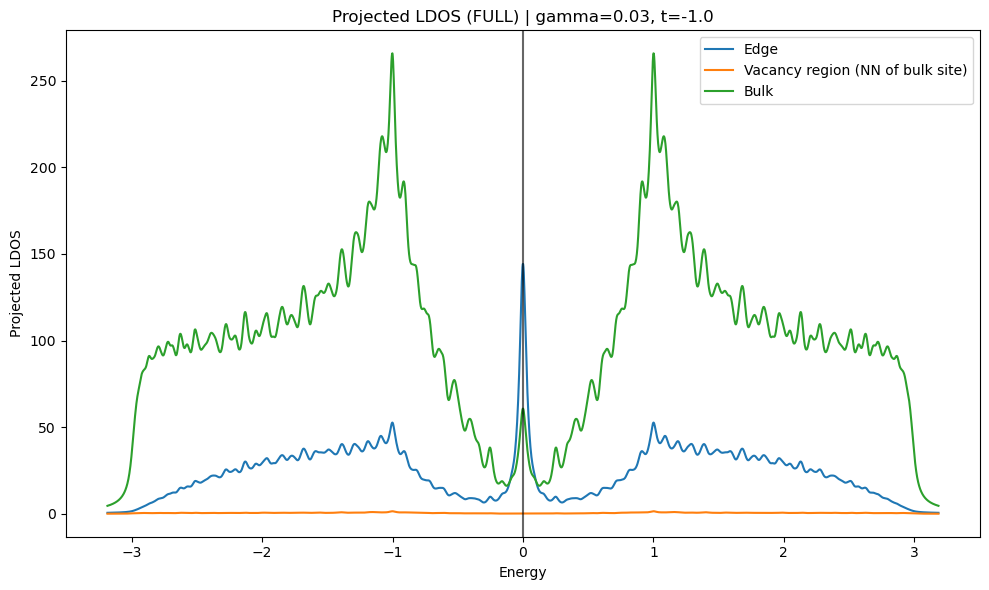

Window |E|<0.1: 22 states


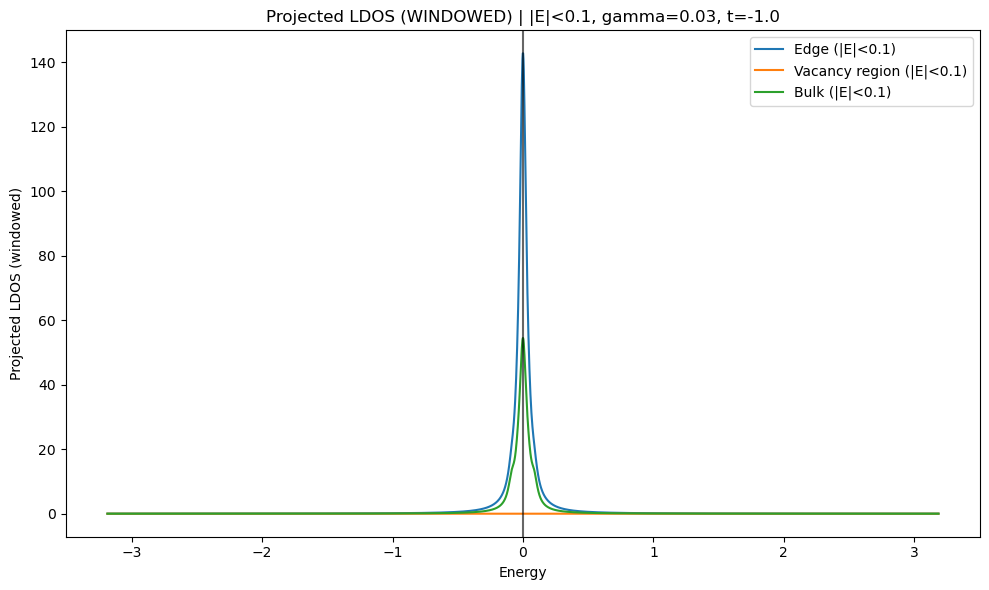

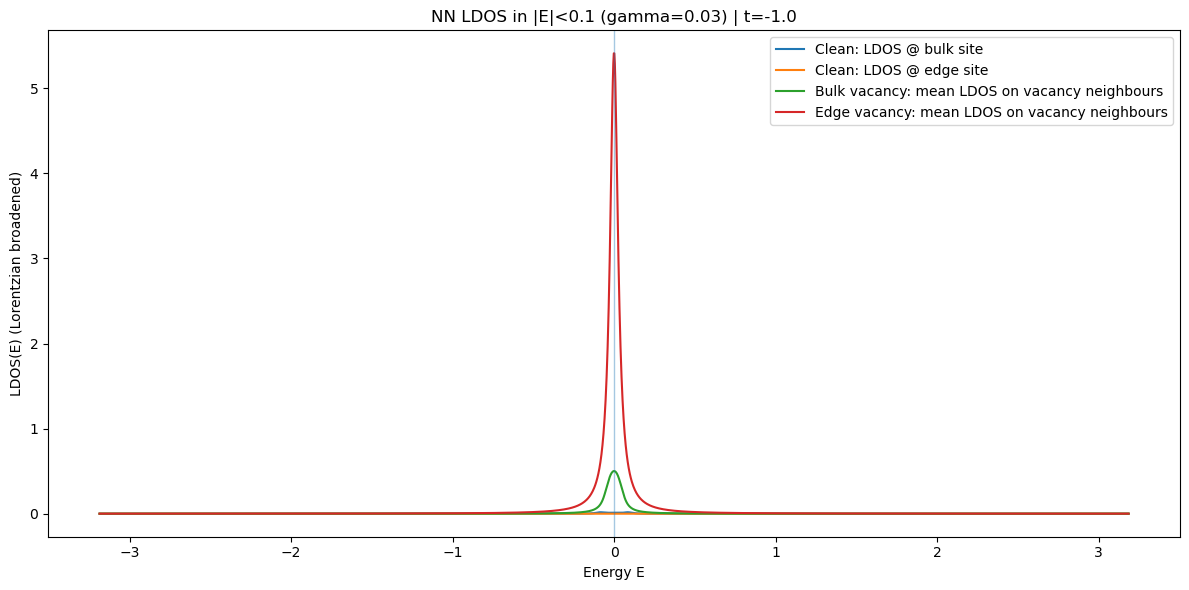

In [8]:
def lorentzian(x, gamma):
    return (gamma / np.pi) / (x*x + gamma*gamma)

def projected_ldos(E_grid, E_levels, P, site_idx, gamma, sel=None):
    """
    Projected LDOS onto region S (sum over sites in S).
    If sel is provided: only include those eigenstates.
    """
    site_idx = np.asarray(site_idx, dtype=int)

    if sel is None:
        E_use = E_levels
        W = P[site_idx, :].sum(axis=0)
    else:
        sel = np.asarray(sel, dtype=int)
        E_use = E_levels[sel]
        W = P[site_idx, :][:, sel].sum(axis=0)

    dE = E_grid[:, None] - E_use[None, :]
    L = lorentzian(dE, gamma)
    return L @ W

# Regions for projection (clean system)
edge_idx = np.array(sorted(list(edge_set)), dtype=int)
bulk_idx = np.array(sorted(list(set(range(N)) - set(edge_idx))), dtype=int)

# Vacancy "region" = NN neighbours of the chosen bulk vacancy site (on clean lattice)
vac_region = neighbours(vac_bulk)

gamma = 0.03
E_grid = np.linspace(float(E0.min()) - 0.2, float(E0.max()) + 0.2, 2500)

# FULL
LDOS_edge_full = projected_ldos(E_grid, E0, P0, edge_idx, gamma)
LDOS_vac_full  = projected_ldos(E_grid, E0, P0, vac_region, gamma)
LDOS_bulk_full = projected_ldos(E_grid, E0, P0, bulk_idx, gamma)

plt.figure(figsize=(10, 6))
plt.plot(E_grid, LDOS_edge_full, label="Edge")
plt.plot(E_grid, LDOS_vac_full,  label="Vacancy region (NN of bulk site)")
plt.plot(E_grid, LDOS_bulk_full, label="Bulk")
plt.axvline(0, color="k", alpha=0.6)
plt.xlabel("Energy")
plt.ylabel("Projected LDOS")
plt.title(f"Projected LDOS (FULL) | gamma={gamma}, t={tb.t}")
plt.legend()
plt.tight_layout()
plt.show()

# WINDOWED
E_cut = 0.1
sel0 = np.where(np.abs(E0) < E_cut)[0]
print(f"Window |E|<{E_cut}: {len(sel0)} states")

LDOS_edge_win = projected_ldos(E_grid, E0, P0, edge_idx, gamma, sel=sel0)
LDOS_vac_win  = projected_ldos(E_grid, E0, P0, vac_region, gamma, sel=sel0)
LDOS_bulk_win = projected_ldos(E_grid, E0, P0, bulk_idx, gamma, sel=sel0)

plt.figure(figsize=(10, 6))
plt.plot(E_grid, LDOS_edge_win, label=f"Edge (|E|<{E_cut})")
plt.plot(E_grid, LDOS_vac_win,  label=f"Vacancy region (|E|<{E_cut})")
plt.plot(E_grid, LDOS_bulk_win, label=f"Bulk (|E|<{E_cut})")
plt.axvline(0, color="k", alpha=0.6)
plt.xlabel("Energy")
plt.ylabel("Projected LDOS (windowed)")
plt.title(f"Projected LDOS (WINDOWED) | |E|<{E_cut}, gamma={gamma}, t={tb.t}")
plt.legend()
plt.tight_layout()
plt.show()

def ldos_site(E_grid, E_levels, weights_n, gamma):
    dE = E_grid[:, None] - E_levels[None, :]
    L = lorentzian(dE, gamma)
    return L @ weights_n

def ldos_site_window(E_grid, E_levels, weights_n, gamma, sel):
    sel = np.asarray(sel, dtype=int)
    if sel.size == 0:
        return np.zeros_like(E_grid)
    return ldos_site(E_grid, E_levels[sel], weights_n[sel], gamma)

def mean_neighbour_weight(P, nb):
    return P[nb, :].mean(axis=0)

gamma = 0.03
Emin = float(min(E0.min(), Eb.min(), Ee.min())) - 0.2
Emax = float(max(E0.max(), Eb.max(), Ee.max())) + 0.2
E_grid2 = np.linspace(Emin, Emax, 2000)

i_bulk_probe = vac_bulk
i_edge_probe = vac_edge
bulk_nb = neighbours(vac_bulk)
edge_nb = neighbours(vac_edge)

use_window = True
E_cut = 0.1

if use_window:
    sel0 = np.where(np.abs(E0) < E_cut)[0]
    selb = np.where(np.abs(Eb) < E_cut)[0]
    sele = np.where(np.abs(Ee) < E_cut)[0]

    LDOS_clean_bulk = ldos_site_window(E_grid2, E0, P0[i_bulk_probe, :], gamma, sel0)
    LDOS_clean_edge = ldos_site_window(E_grid2, E0, P0[i_edge_probe, :], gamma, sel0)

    w_bulk_nb = mean_neighbour_weight(Pb, bulk_nb)
    w_edge_nb = mean_neighbour_weight(Pe, edge_nb)

    LDOS_bulkvac_nb = ldos_site_window(E_grid2, Eb, w_bulk_nb, gamma, selb)
    LDOS_edgevac_nb = ldos_site_window(E_grid2, Ee, w_edge_nb, gamma, sele)

    title = f"NN LDOS in |E|<{E_cut} (gamma={gamma}) | t={tb.t}"
else:
    LDOS_clean_bulk = ldos_site(E_grid2, E0, P0[i_bulk_probe, :], gamma)
    LDOS_clean_edge = ldos_site(E_grid2, E0, P0[i_edge_probe, :], gamma)

    w_bulk_nb = mean_neighbour_weight(Pb, bulk_nb)
    w_edge_nb = mean_neighbour_weight(Pe, edge_nb)

    LDOS_bulkvac_nb = ldos_site(E_grid2, Eb, w_bulk_nb, gamma)
    LDOS_edgevac_nb = ldos_site(E_grid2, Ee, w_edge_nb, gamma)

    title = f"NN LDOS (gamma={gamma}) | t={tb.t}"

plt.figure(figsize=(12, 6))
plt.plot(E_grid2, LDOS_clean_bulk, label="Clean: LDOS @ bulk site")
plt.plot(E_grid2, LDOS_clean_edge, label="Clean: LDOS @ edge site")
plt.plot(E_grid2, LDOS_bulkvac_nb, label="Bulk vacancy: mean LDOS on vacancy neighbours")
plt.plot(E_grid2, LDOS_edgevac_nb, label="Edge vacancy: mean LDOS on vacancy neighbours")
plt.axvline(0, linewidth=1, alpha=0.4)
plt.xlabel("Energy E")
plt.ylabel("LDOS(E) (Lorentzian broadened)")
plt.title(title)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Sum rule for clean (full spectrum only):
DOS_clean = ldos_site(E_grid2, E0, np.ones_like(E0), gamma)
LDOS_sum_clean = np.zeros_like(E_grid2)
for i in range(N):
    LDOS_sum_clean += ldos_site(E_grid2, E0, P0[i, :], gamma)

rel_err = np.max(np.abs(LDOS_sum_clean - DOS_clean)) / (np.max(np.abs(DOS_clean)) + 1e-30)
print("LDOS sum rule (clean, full spectrum) max rel error:", float(rel_err))

print("Edge probe is_edge?", i_edge_probe in edge_set, "NN degree:", int(C[i_edge_probe].sum()))
print("Bulk probe is_edge?", i_bulk_probe in edge_set, "NN degree:", int(C[i_bulk_probe].sum()))


LDOS sum rule (clean, full spectrum) max rel error: 1.962843895603478e-15
Edge probe is_edge? True NN degree: 2
Bulk probe is_edge? False NN degree: 3
